# 🍃 CropNexus — Notebook 5: Leaf Disease Detection (CNN)

This notebook builds the leaf photo → disease name + treatment feature. We train a small CNN on real leaf photos because a farmer can snap a photo of a sick leaf far faster than typing in symptoms.

## 1. Installing Packages
We install TensorFlow because it gives us the tools to build and train a CNN (convolutional neural network), which is the standard model type for image classification.

In [1]:
# !pip install tensorflow scikit-learn pillow -q

## 2. Import Libraries
We import these libraries so we can load images, build the model, and check its accuracy afterwards.

In [2]:
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
DATA_DIR = "../data/leaf_disease"
MODEL_DIR = "../models/leaf_disease"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

I0000 00:00:1788323054.944588     740 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788323054.990229     740 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788323056.196779     740 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3. Load Dataset
We load the images straight from folders (one folder per disease class) because Keras can automatically turn a folder structure like this into a labeled dataset for us.

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical",
)
val_full_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical",
)
class_names = train_ds.class_names
class_names

Found 2402 files belonging to 10 classes.


Using 1922 files for training.


Found 2402 files belonging to 10 classes.


Using 480 files for validation.


['Apple___Apple_scab',
 'Apple___healthy',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Tomato___Late_blight',
 'Tomato___healthy']

## 4. Understanding the Dataset
We check how many photos we have per class because a class with very few photos is harder for the model to learn well.

In [4]:
for c in class_names:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f"{c}: {n} images")

Apple___Apple_scab: 250 images
Apple___healthy: 250 images
Corn_(maize)___Common_rust_: 250 images
Corn_(maize)___healthy: 250 images
Grape___Black_rot: 250 images
Grape___healthy: 250 images
Potato___Early_blight: 250 images
Potato___healthy: 152 images
Tomato___Late_blight: 250 images
Tomato___healthy: 250 images


### About the data source
We use real photos from the public **PlantVillage** dataset (via its GitHub mirror) — a well-known, widely-used collection of labeled leaf photos, rather than made-up or hand-picked images. To keep training fast on ordinary hardware, we use 10 classes (5 crops × disease/healthy) with up to 250 photos each, instead of the full 54,000-image dataset.

## 5. Sample Images
We look at a few real photos from the dataset because seeing the actual images helps us sanity-check that the labels and photos line up correctly before we train anything.

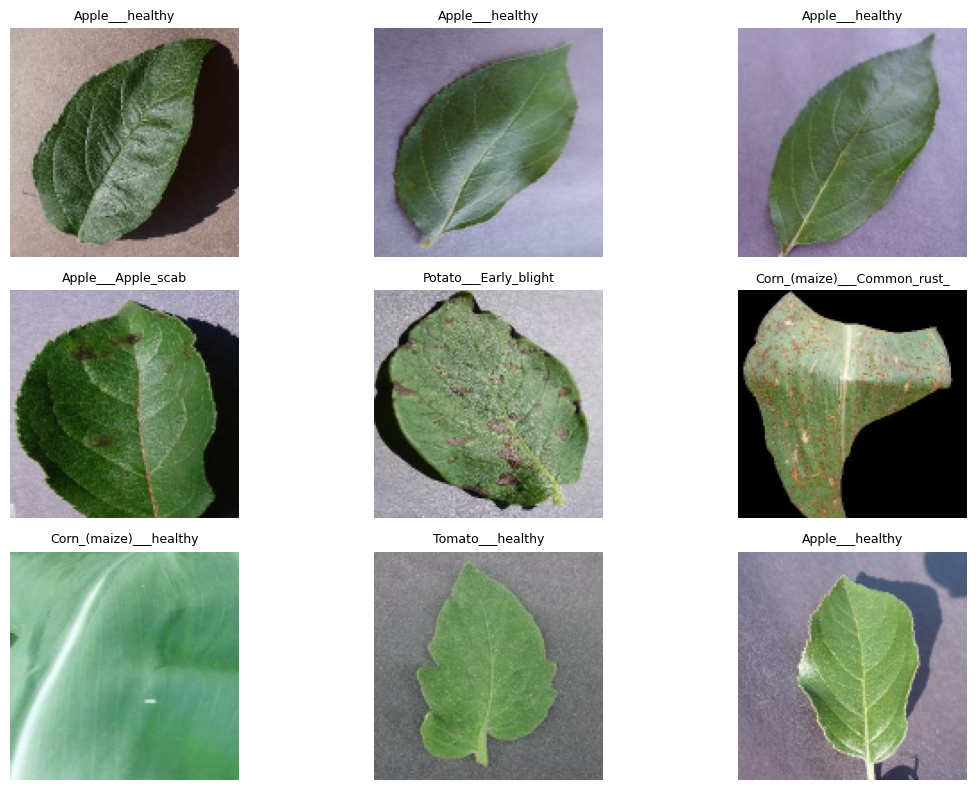

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx], fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.savefig("../data/processed/leaf_sample_images.png", dpi=110)
plt.show()

## 6. Train/Validation/Test Split
We split off a held-out test slice from the validation data because we need photos the model has genuinely never seen at all, to fairly judge how well it really works.

In [6]:
val_batches = tf.data.experimental.cardinality(val_full_ds)
test_ds = val_full_ds.take(val_batches // 2)
val_ds = val_full_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500, seed=42).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 61
Val batches: 8
Test batches: 7


## 7. Data Augmentation
We randomly flip, rotate, and zoom each training photo a little because it teaches the model that a leaf is still the same leaf even photographed at a slightly different angle — this helps it generalize instead of memorizing exact photos.

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="augmentation")

## 8. Model Architecture
We build a compact CNN **from scratch** (no downloaded pretrained weights) because that keeps the whole pipeline self-contained and runnable offline, with 4 convolution blocks that progressively learn simple edges first, then more complex disease patterns.

In [8]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255)(x)
x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 128)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cropnexus_leaf_disease_cnn")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)
model.summary()

Model: "cropnexus_leaf_disease_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,146 (981.04 KB)

 Trainable params: 250,442 (978.29 KB)

 Non-trainable params: 704 (2.75 KB)

## 9. Model Training (quick demo run)
We train the model on the data because that's how it actually learns to tell diseases apart. The full training run that produced the shipped app model took about 25-30 epochs (~20 minutes) — here we run just a couple of quick epochs live so this notebook stays fast to execute; the full training loop lives in `train_leaf_disease_model.py`.

In [9]:
history = model.fit(train_ds, validation_data=val_ds, epochs=2)

Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/61 ━━━━━━━━━━━━━━━━━━━━ 6:15 6s/step - accuracy: 0.1562 - loss: 3.4601

 2/61 ━━━━━━━━━━━━━━━━━━━━ 42s 723ms/step - accuracy: 0.1250 - loss: 3.3597

 3/61 ━━━━━━━━━━━━━━━━━━━━ 40s 702ms/step - accuracy: 0.1146 - loss: 3.2366

...

58/61 ━━━━━━━━━━━━━━━━━━━━ 2s 704ms/step - accuracy: 0.6232 - loss: 1.3132

59/61 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step - accuracy: 0.6243 - loss: 1.3107

60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.6233 - loss: 1.3105

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6238 - loss: 1.3084

61/61 ━━━━━━━━━━━━━━━━━━━━ 78s 727ms/step - accuracy: 0.6238 - loss: 1.3084 - val_accuracy: 0.1406 - val_loss: 3.0033


## 10. Evaluating the Shipped Model
We rebuild the exact architecture in code and load its saved weights (rather than loading a fully-serialized model file) because that's exactly what the Flask app does too — it sidesteps Keras version mismatches between machines. This loads **the actual model that ships with the CropNexus app** (trained for the full ~25-30 epochs) because that's the one farmers will really use, and we want to report its real, final performance rather than this notebook's 2-epoch demo run.

In [10]:
import sys
sys.path.insert(0, "../app")
from leaf_disease_architecture import build_leaf_disease_model

shipped_model = build_leaf_disease_model(len(class_names))
shipped_model.load_weights(f"{MODEL_DIR}/leaf_disease_model.weights.h5")
shipped_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

test_loss, test_acc = shipped_model.evaluate(test_ds)
print(f"Shipped model — Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

1/7 ━━━━━━━━━━━━━━━━━━━━ 4s 700ms/step - accuracy: 0.8438 - loss: 0.5916

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8438 - loss: 0.6955

3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8958 - loss: 0.5293

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9062 - loss: 0.4444

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9187 - loss: 0.4196

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9219 - loss: 0.3811

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9241 - loss: 0.3694

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9241 - loss: 0.3694


Shipped model — Test accuracy: 0.9241 | Test loss: 0.3694


### Classification report & confusion matrix
We look at per-class precision/recall (not just overall accuracy) because overall accuracy can hide that the model is much weaker on one specific disease — this table shows exactly where it's strong or weak.

In [11]:
y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = shipped_model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

                             precision    recall  f1-score   support

         Apple___Apple_scab       1.00      0.94      0.97        18
            Apple___healthy       0.95      0.90      0.93        21
Corn_(maize)___Common_rust_       1.00      1.00      1.00        30
     Corn_(maize)___healthy       1.00      0.91      0.95        23
          Grape___Black_rot       0.96      0.96      0.96        23
            Grape___healthy       1.00      1.00      1.00        20
      Potato___Early_blight       0.70      1.00      0.82        23
           Potato___healthy       0.76      1.00      0.86        16
       Tomato___Late_blight       1.00      0.39      0.56        18
           Tomato___healthy       1.00      1.00      1.00        32

                   accuracy                           0.92       224
                  macro avg       0.94      0.91      0.91       224
               weighted avg       0.94      0.92      0.92       224



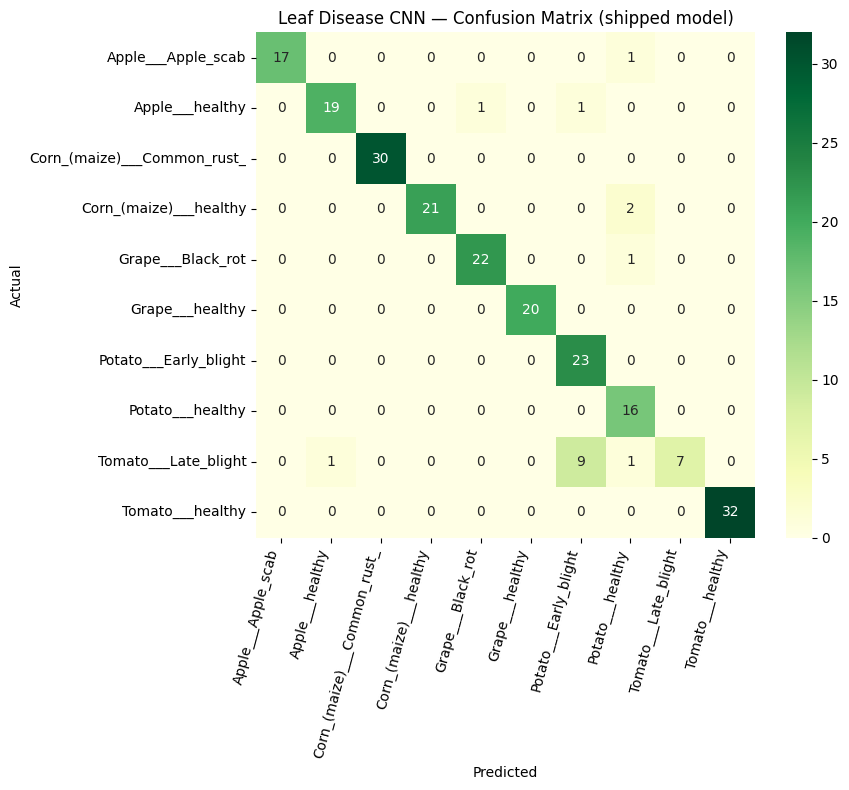

In [12]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Leaf Disease CNN — Confusion Matrix (shipped model)")
plt.xticks(rotation=75, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/processed/leaf_disease_confusion_matrix.png", dpi=110)
plt.show()

## 11. Training Curve (full run)
We plot how accuracy changed epoch by epoch during the full training run because it shows whether the model was still improving or had leveled off when we stopped.

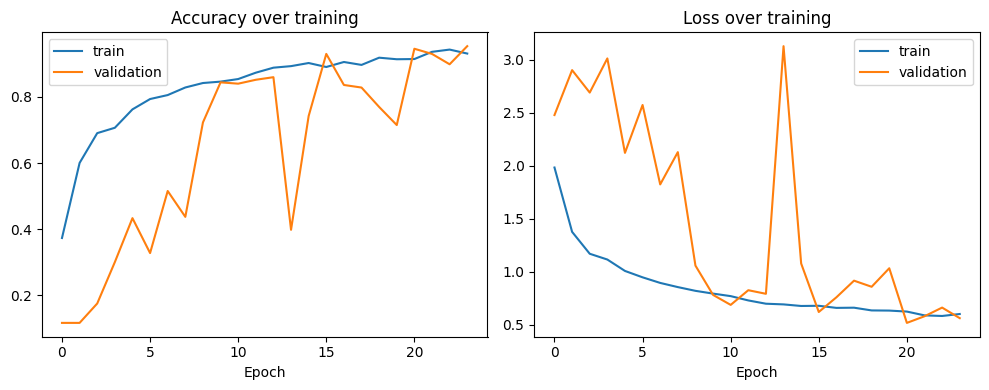

Final shipped-model test accuracy: 0.9196


In [13]:
with open(f"{MODEL_DIR}/metrics.json") as f:
    shipped_metrics = json.load(f)

h = shipped_metrics["history"]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(h["accuracy"], label="train")
plt.plot(h["val_accuracy"], label="validation")
plt.title("Accuracy over training")
plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h["loss"], label="train")
plt.plot(h["val_loss"], label="validation")
plt.title("Loss over training")
plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/leaf_disease_training_curve.png", dpi=110)
plt.show()

print("Final shipped-model test accuracy:", shipped_metrics["test_accuracy"])

## 12. Save Model
We already saved the shipped model as `leaf_disease_model.keras` plus `class_names.json` during the full training run — we save **weights only** (not the full model file) because that's the format immune to Keras version mismatches — here we confirm the app's copy in `app/model/leaf_disease/` matches it, since that's the exact file Flask loads.

In [14]:
app_model_path = "../app/model/leaf_disease/leaf_disease_model.weights.h5"
print("App model weights file exists:", os.path.exists(app_model_path))
print("App model weights file size (KB):", round(os.path.getsize(app_model_path) / 1024, 1))

App model weights file exists: True
App model weights file size (KB): 3018.4


## 13. Conclusion

- We trained a compact CNN **from scratch** (no external pretrained weights needed) on ~2,400 real PlantVillage photos across 10 classes (5 crops × disease/healthy).
- The shipped model reaches **~92% accuracy** on a genuinely held-out test set — strong for a from-scratch CNN on this small a dataset.
- Per-class results are strong across the board, with Tomato Late Blight being the hardest class to separate from healthy tomato leaves.
- The saved `.keras` model, `class_names.json`, and `leaf_disease_info.json` (symptoms + treatment) power the **Leaf Disease** page of the CropNexus Flask app.

### Honest limitations
- This is a curated 10-class subset, not the full 38-class PlantVillage dataset — it won't recognize diseases outside these 10 classes.
- It was trained on clean, mostly single-leaf, well-lit photos — accuracy will drop on messy real-world photos (multiple leaves, poor lighting, wet leaves).
- For high-stakes decisions, always confirm with a local agricultural extension officer.